# CNOT Scheduling Visualization: Perpendicular vs Parallel

Compares FT (`perpendicular`) vs non-FT (`parallel`) scheduling for the Rotated Surface Code.

**Key difference — Ticks 2 & 3:**
- `perpendicular`: X-stab and Z-stab probe in **opposite** directions → hook errors cancel
- `parallel`: X-stab and Z-stab probe in the **same** direction → hook errors accumulate


In [8]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from src.ir.qec_system import QECSystem
from src.noise.config import NoiseConfig
from experiments.memory import MemoryExperiment

## 1. Build circuits for both schedules

In [9]:
d = 3
noise_params = NoiseConfig(p_idle=1e-3, p_meas=1e-3, p_reset=1e-3, p_1q=1e-3, p_2q=1e-3)

circuits = {}
for sched in ['perpendicular', 'parallel']:
    code = RotatedSurfaceCode(distance=d)
    system = QECSystem()
    system.add_patch(code, name='rotated_sc')
    exp = MemoryExperiment(
        qec_system=system,
        extraction_block_class=RotatedSurfaceCodeExtractionBlock,
        rounds=d,
        noise_params=noise_params,
        noise_model='circuit_level',
        basis='Z',
        se_block_kwargs={'scheduling': sched},
    )
    circuits[sched] = exp.build()
    print(f'{sched}: {circuits[sched].num_qubits} qubits, {len(list(circuits[sched].detector_error_model().flattened()))} DEM instructions')

Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
perpendicular: 17 qubits, 243 DEM instructions
Writing coordinates...
Initializing...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Applying rest rounds of syndrome extraction...
Measuring data qubits...
Injecting noise...
parallel: 17 qubits, 223 DEM instructions


## 2. Stim detector-slice diagrams (spacetime view)

Shows how detectors connect in spacetime. Hook errors in `parallel` create diagonal connections that span 2 time steps — the signature of reduced effective distance.

=== PERPENDICULAR (FT) ===


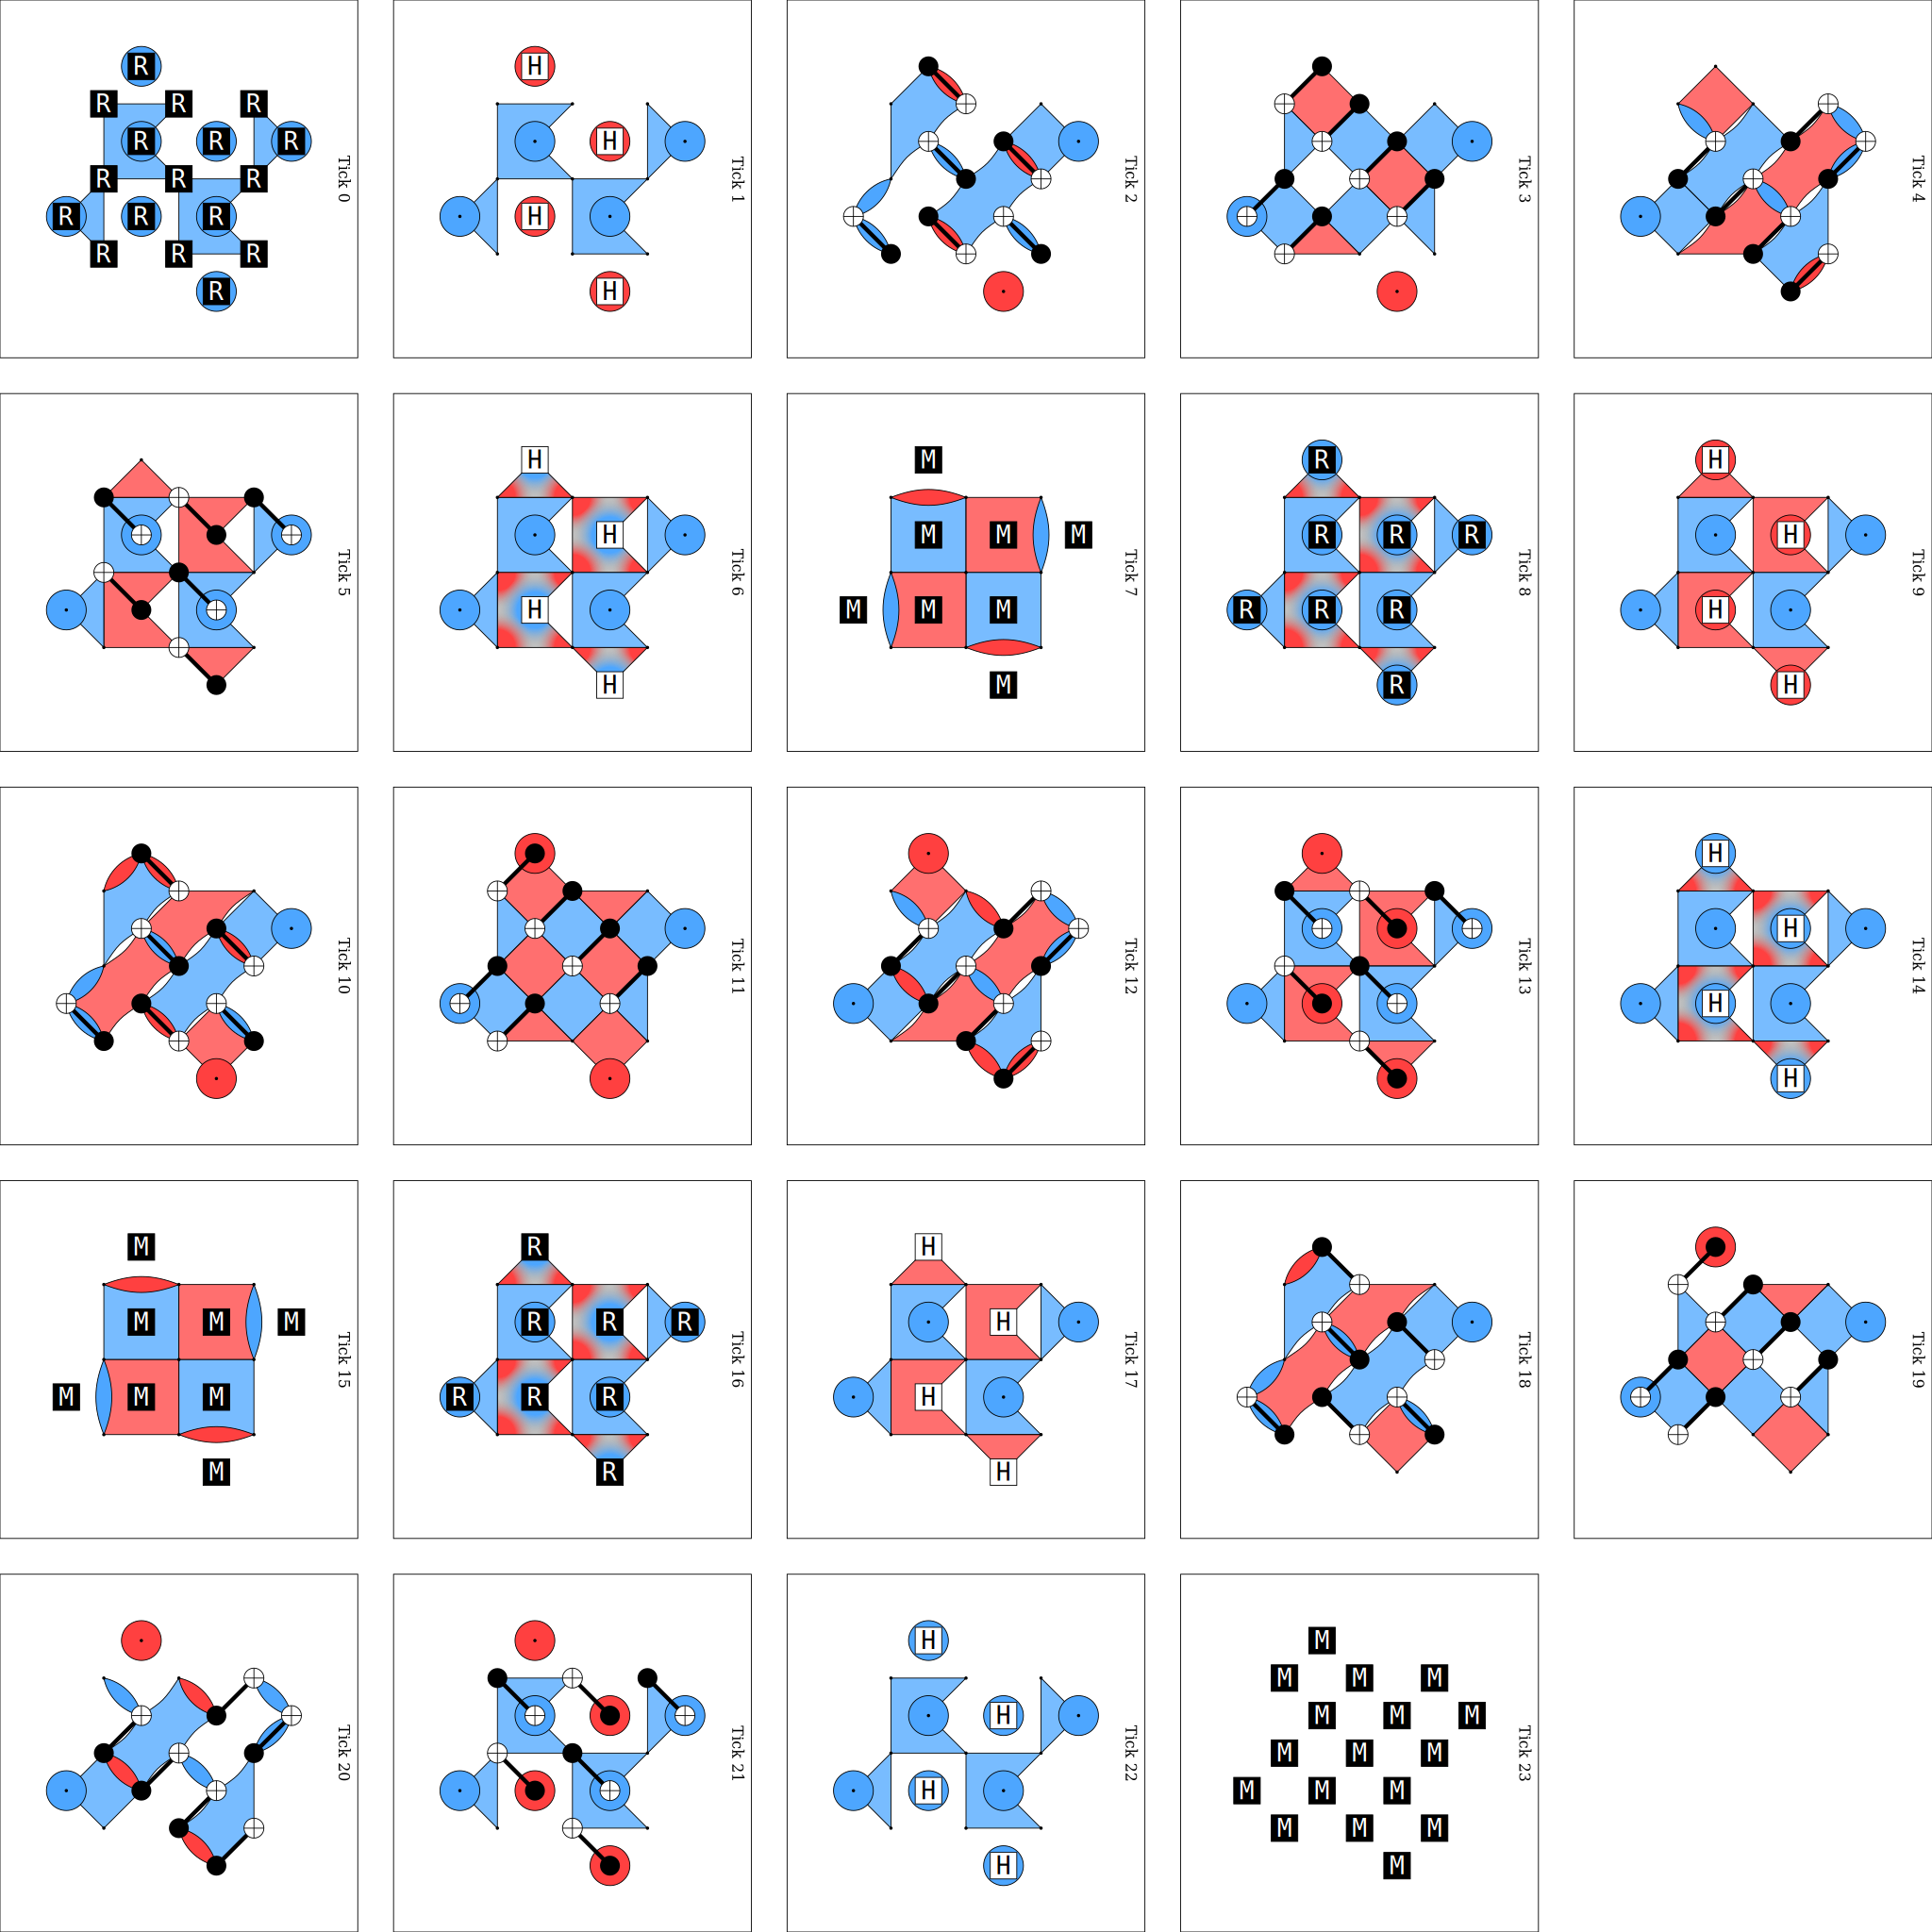

In [16]:
print("=== PERPENDICULAR (FT) ===")
circuits['perpendicular'].without_noise().diagram('detslice-with-ops-svg')

=== PARALLEL (non-FT) ===


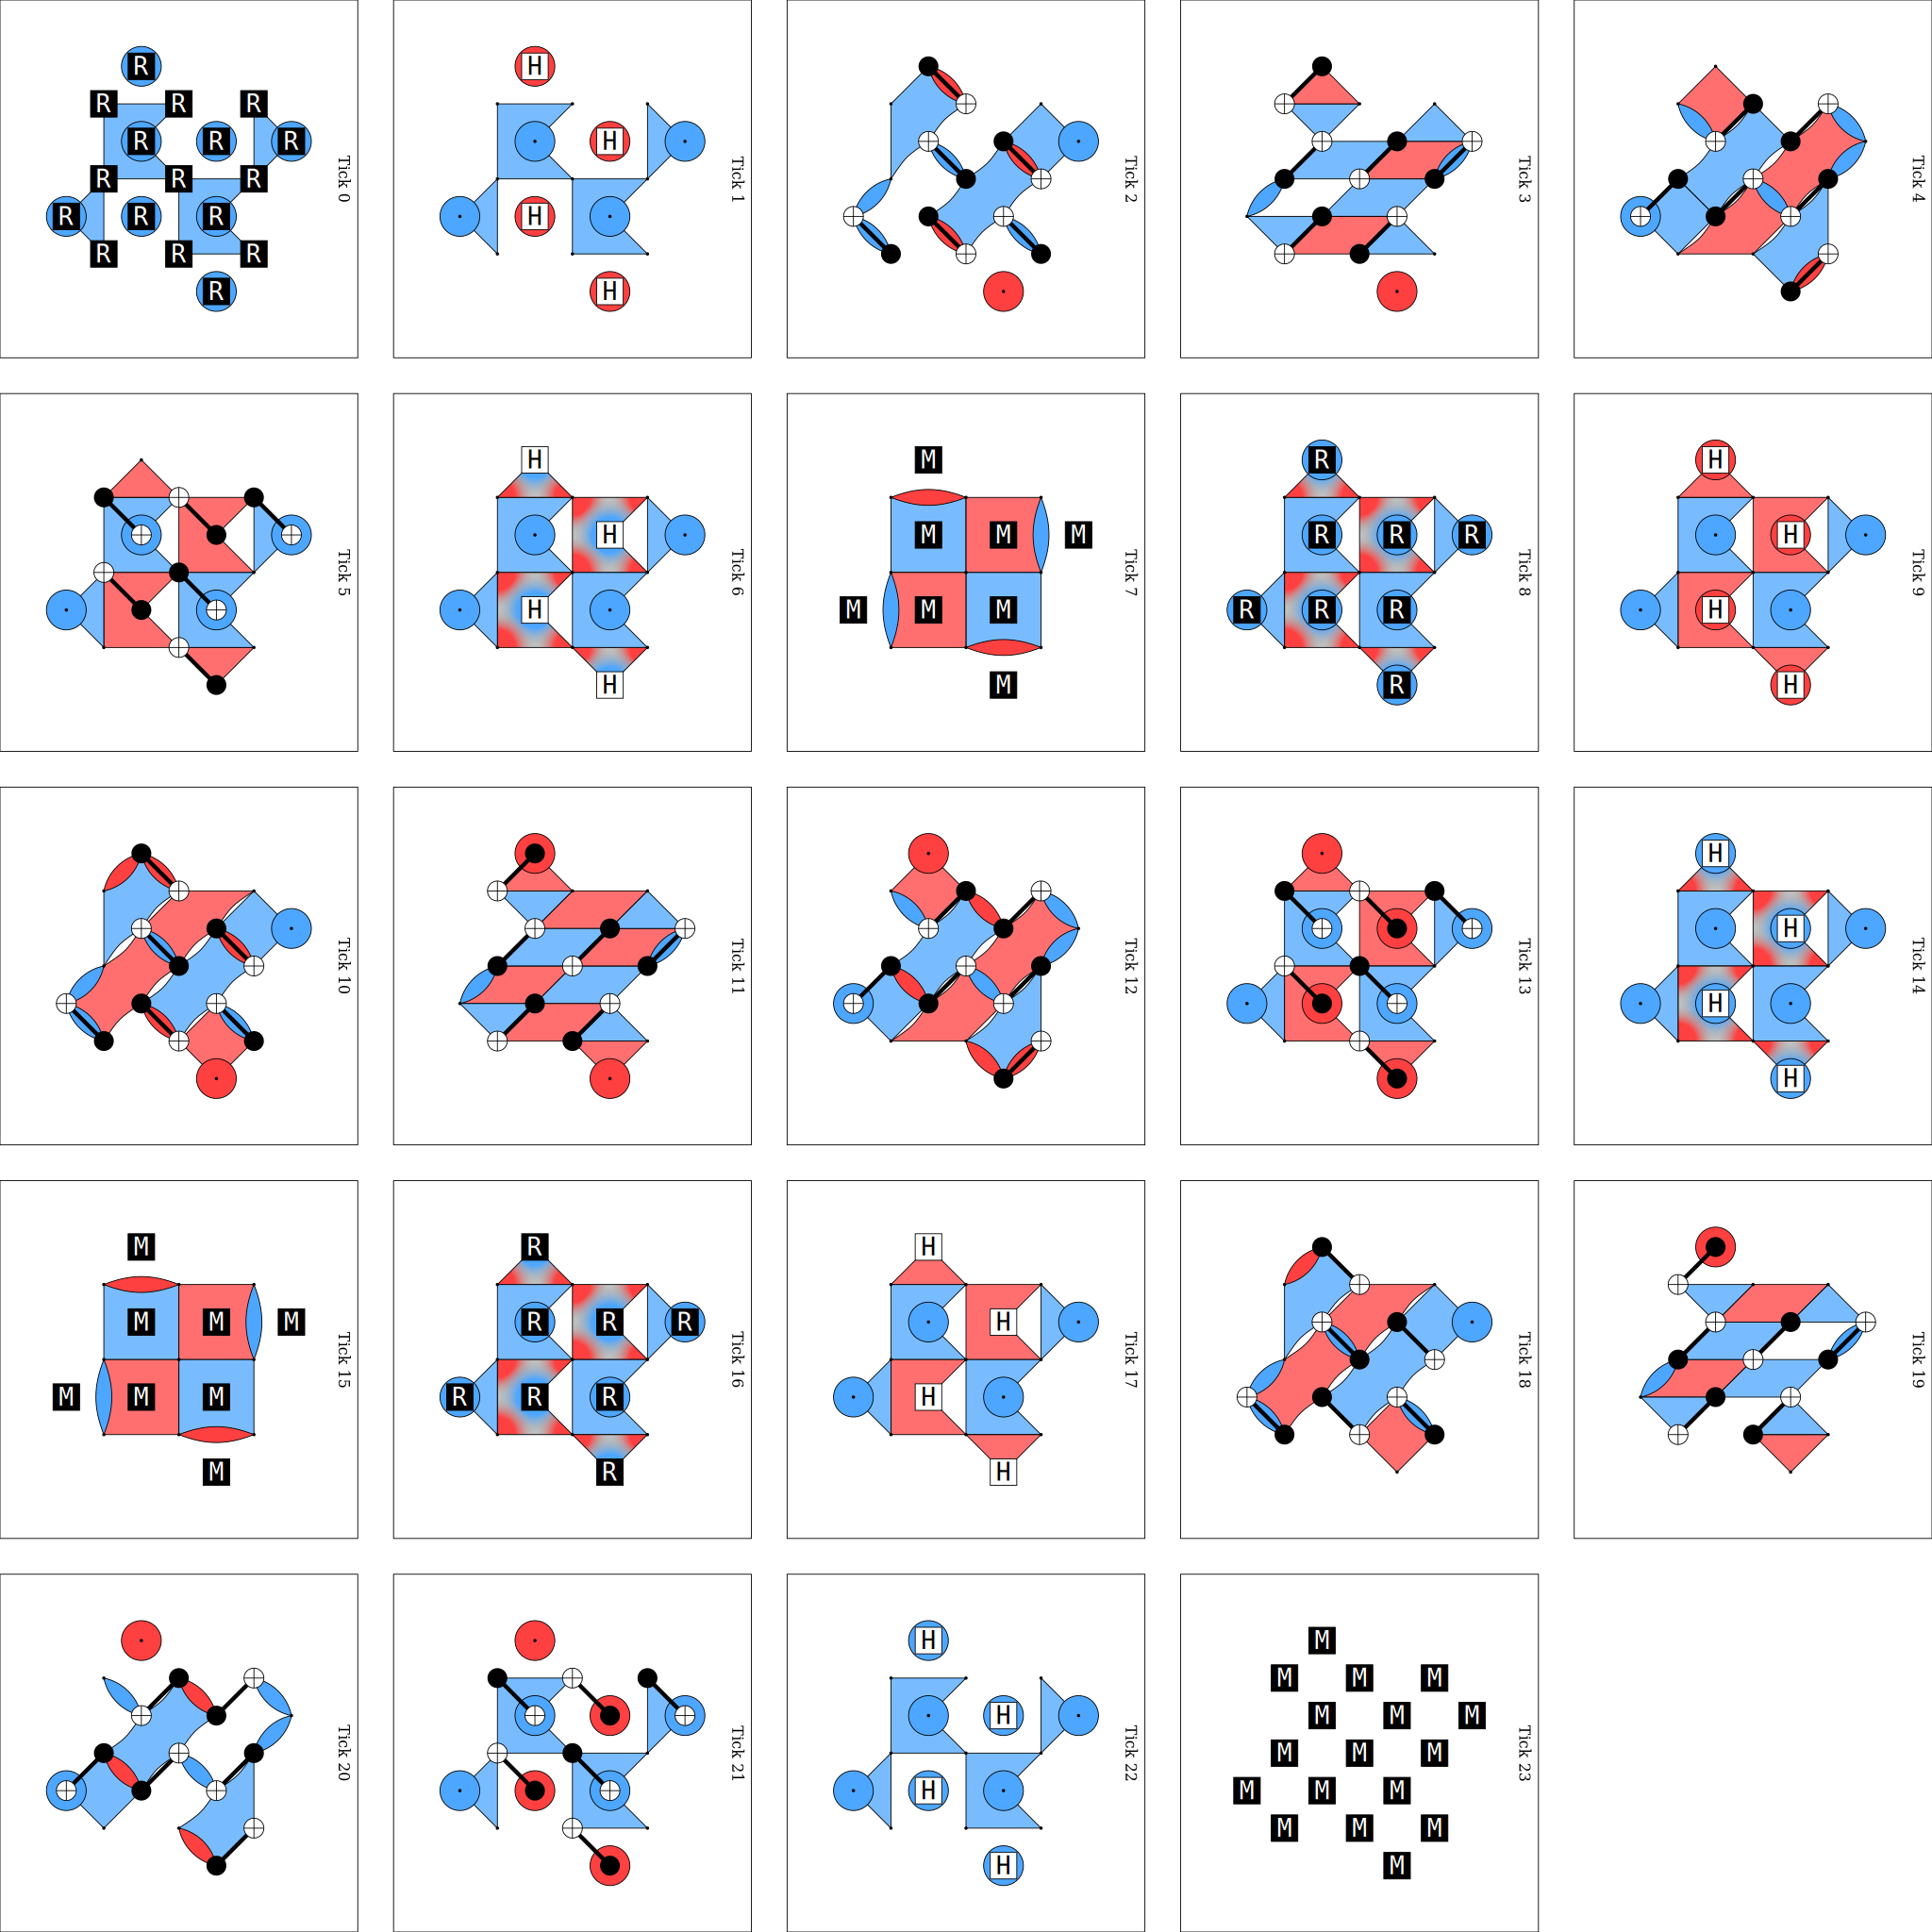

In [17]:
print("=== PARALLEL (non-FT) ===")
circuits['parallel'].without_noise().diagram('detslice-with-ops-svg')

## 3. Per-tick CNOT pattern on the qubit lattice

Draws the CNOT directions for each of the 4 ticks side by side. X-stabilizer interactions in red, Z-stabilizer interactions in blue.

In `perpendicular`: Ticks 2 & 3 — red and blue arrows point in **opposite** directions.  
In `parallel`: Ticks 2 & 3 — red and blue arrows point in the **same** direction.

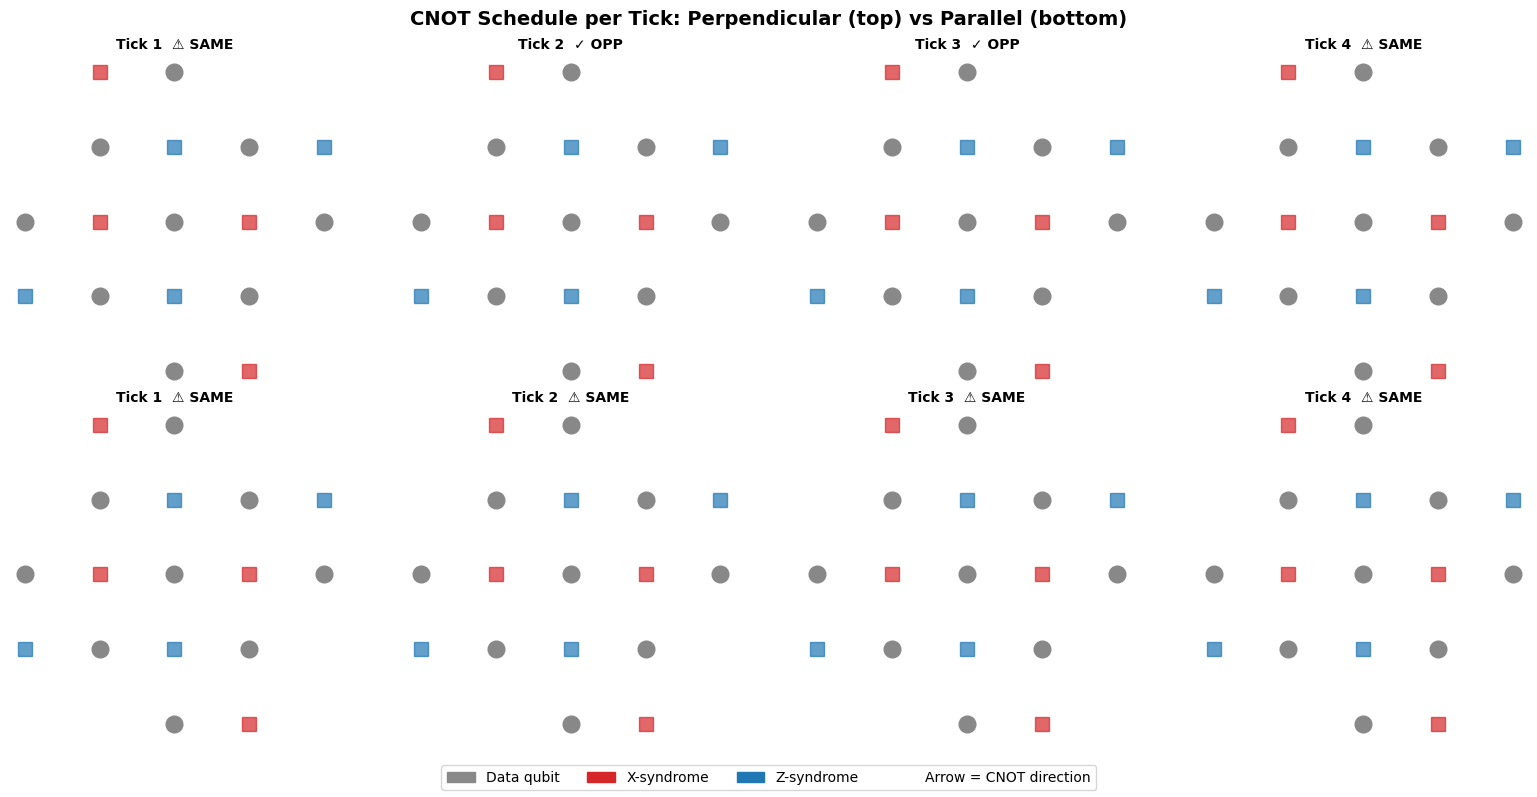

In [12]:
SCHEDULES = {
    'perpendicular': [
        ((+1, +1), (+1, +1)),
        ((-1, +1), (+1, -1)),
        ((+1, -1), (-1, +1)),
        ((-1, -1), (-1, -1)),
    ],
    'parallel': [
        ((+1, +1), (+1, +1)),
        ((-1, +1), (-1, +1)),
        ((+1, -1), (+1, -1)),
        ((-1, -1), (-1, -1)),
    ],
}

# Build d=3 rotated SC lattice (data + syndrome positions)
code = RotatedSurfaceCode(distance=d)
code.rotate_coords(np.pi / 4)

data_coords  = {idx: code.qubit_coords[idx] for idx in code.data_indices}
x_syn_coords = {idx: code.qubit_coords[idx] for idx in code.syndrome_indices_x}
z_syn_coords = {idx: code.qubit_coords[idx] for idx in code.syndrome_indices_z}

# coord → data index lookup
coord_to_data = {tuple(np.round(v, 6)): k for k, v in data_coords.items()}

def plot_tick(ax, tick_idx, dx_x, dx_z):
    """Draw the CNOT interactions for one tick on ax."""
    for coord in data_coords.values():
        ax.plot(*coord, 'o', color='#888888', markersize=12, zorder=3)
    for coord in x_syn_coords.values():
        ax.plot(*coord, 's', color='#d62728', markersize=10, zorder=3, alpha=0.7)
    for coord in z_syn_coords.values():
        ax.plot(*coord, 's', color='#1f77b4', markersize=10, zorder=3, alpha=0.7)

    arrow_kw = dict(arrowstyle='->', mutation_scale=15, lw=2, zorder=4)

    # X-stabilizer CNOTs (syn → data, red)
    for idx, sc in x_syn_coords.items():
        tc = (round(sc[0] + dx_x[0], 6), round(sc[1] + dx_x[1], 6))
        if tc in coord_to_data:
            ax.annotate('', xy=tc, xytext=sc,
                        arrowprops=dict(color='#d62728', **arrow_kw))

    # Z-stabilizer CNOTs (data → syn, blue)
    for idx, sc in z_syn_coords.items():
        tc = (round(sc[0] + dx_z[0], 6), round(sc[1] + dx_z[1], 6))
        if tc in coord_to_data:
            dc = data_coords[coord_to_data[tc]]
            ax.annotate('', xy=sc, xytext=dc,
                        arrowprops=dict(color='#1f77b4', **arrow_kw))

    same = '⚠ SAME' if dx_x == dx_z else '✓ OPP'
    ax.set_title(f'Tick {tick_idx+1}  {same}', fontsize=10, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('CNOT Schedule per Tick: Perpendicular (top) vs Parallel (bottom)',
             fontsize=14, fontweight='bold')

for row, sched_name in enumerate(['perpendicular', 'parallel']):
    for tick_idx, (dx_x, dx_z) in enumerate(SCHEDULES[sched_name]):
        plot_tick(axes[row, tick_idx], tick_idx, dx_x, dx_z)
    axes[row, 0].set_ylabel(sched_name.upper(), fontsize=11, fontweight='bold',
                            rotation=90, labelpad=8)

legend_elements = [
    mpatches.Patch(color='#888888', label='Data qubit'),
    mpatches.Patch(color='#d62728', label='X-syndrome'),
    mpatches.Patch(color='#1f77b4', label='Z-syndrome'),
    mpatches.Patch(color='white', label='Arrow = CNOT direction'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 4. Highlight the hook error mechanism

A single CNOT error in Tick 2 of the `parallel` schedule creates a hook error:
- The error propagates along the shared direction of X and Z probes
- This effectively creates a weight-2 error that looks like a single error to the decoder
- Result: effective distance halved (d → ⌊d/2⌋ + 1)

In `perpendicular`, Ticks 2 & 3 probe in opposite directions, so hook errors on X-stabs and Z-stabs are spatially separated and cannot combine into a logical error path.

In [13]:
# Print the SE block circuits side by side to confirm the difference
for sched in ['perpendicular', 'parallel']:
    code = RotatedSurfaceCode(distance=d)
    code.rotate_coords(np.pi / 4)
    system = QECSystem()
    system.add_patch(code, name='rotated_sc')
    se_block = RotatedSurfaceCodeExtractionBlock(system, scheduling=sched)
    print(f'\n=== {sched.upper()} SE block circuit ===')
    print(se_block.circuit)


=== PERPENDICULAR SE block circuit ===
R 0 4 5 6 10 11 12 16
TICK[SE_start]
H 0 6 12 16
TICK
CX 0 2 6 9 12 14 8 4 13 10 15 11
TICK
CX 0 1 6 8 12 13 2 4 7 10 9 11
TICK
CX 6 3 12 8 16 15 7 4 9 5 14 11
TICK
CX 6 2 12 7 16 14 1 4 3 5 8 11
TICK
H 0 6 12 16
TICK
M 0 4 5 6 10 11 12 16

=== PARALLEL SE block circuit ===
R 0 4 5 6 10 11 12 16
TICK[SE_start]
H 0 6 12 16
TICK
CX 0 2 6 9 12 14 8 4 13 10 15 11
TICK
CX 0 1 6 8 12 13 7 4 9 5 14 11
TICK
CX 6 3 12 8 16 15 2 4 7 10 9 11
TICK
CX 6 2 12 7 16 14 1 4 3 5 8 11
TICK
H 0 6 12 16
TICK
M 0 4 5 6 10 11 12 16


## 5. DEM comparison: number of hyperedges

The `parallel` schedule should produce more complex hyperedges in the Detector Error Model (longer chains), while `perpendicular` keeps hyperedges local.

In [14]:
for sched in ['perpendicular', 'parallel']:
    dem = circuits[sched].detector_error_model(decompose_errors=False)
    instructions = list(dem.flattened())
    error_instrs = [i for i in instructions if i.type == 'error']
    weights = [len([t for t in i.targets_copy() if t.is_relative_detector_id()]) for i in error_instrs]
    print(f'{sched}:')
    print(f'  Total error mechanisms: {len(error_instrs)}')
    print(f'  Weight-1 errors: {weights.count(1)}')
    print(f'  Weight-2 errors: {weights.count(2)}')
    print(f'  Weight-3+ errors: {sum(1 for w in weights if w >= 3)}')
    print()

perpendicular:
  Total error mechanisms: 219
  Weight-1 errors: 24
  Weight-2 errors: 82
  Weight-3+ errors: 113

parallel:
  Total error mechanisms: 199
  Weight-1 errors: 24
  Weight-2 errors: 76
  Weight-3+ errors: 99

